In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('2-multiplegradesdataset.csv')

In [3]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


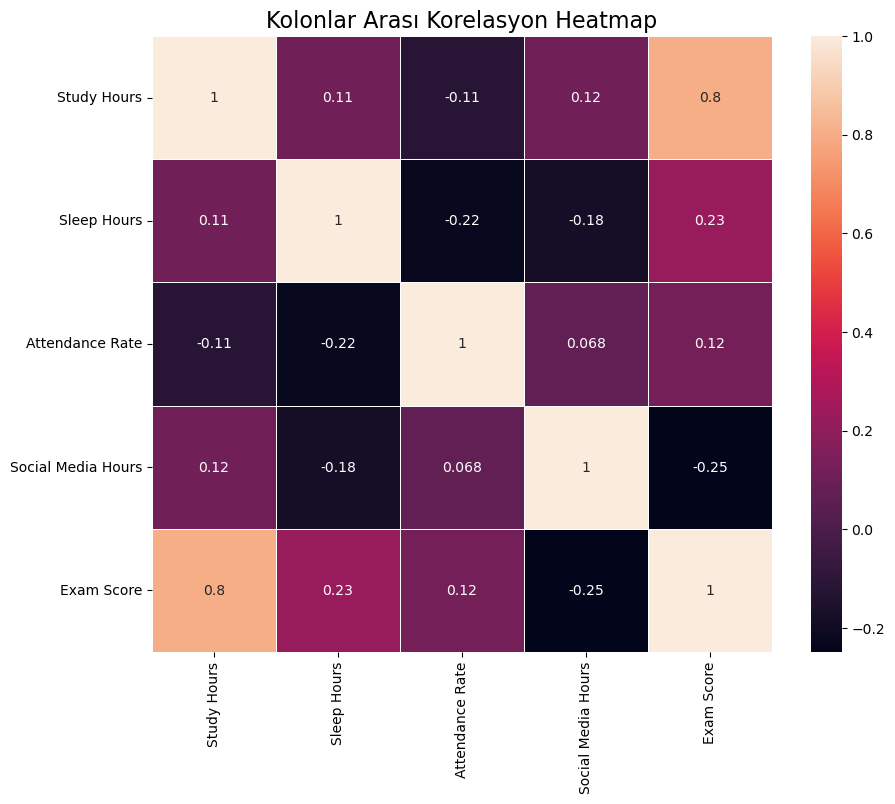

In [4]:
plt.figure(figsize=(10,8))  # grafiğin boyutunu ayarlıyoruz
sns.heatmap(df.corr(),      # sadece kolonlar arasındaki korelasyon
            annot=True,     # hücrelerin içine sayı yaz
            linewidths=0.5) # kutuların arasına ince çizgi koy
plt.title("Kolonlar Arası Korelasyon Heatmap", fontsize=16)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

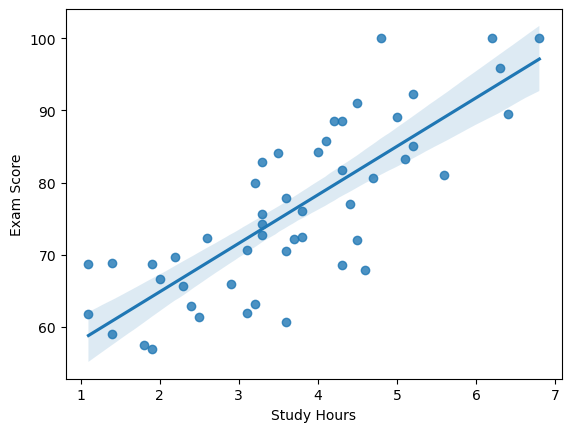

In [5]:
sns.regplot(data = df , x = 'Study Hours' , y = 'Exam Score') # BEST FIT LINE CIZEREK VERIR
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

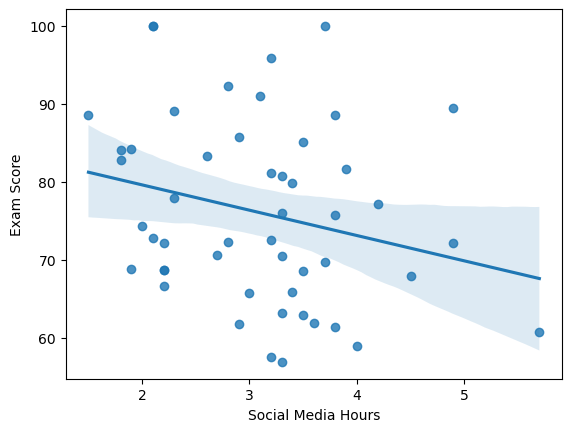

In [6]:
sns.regplot(data = df , x = 'Social Media Hours' , y = 'Exam Score') # BEST FIT LINE CIZEREK VERIR
plt.show

In [7]:
df.head()

,Study Hours,Sleep Hours,Attendance Rate,Social Media Hours,Exam Score
0,4.7,7.3,82.9,3.3,80.7
1,3.8,6.6,87.9,3.3,76.0
2,5.0,6.3,88.3,2.3,89.1
3,6.3,7.6,86.0,3.2,95.9
4,3.6,8.0,89.2,3.3,70.5


In [8]:
# Eğitim aşaması 

In [9]:
# X = df.iloc[:,:-1] -->> DataFrame'in sonuncu elemanı haric elemanlarını alır
# y = df.iloc[:,-1] -->> DataFrame'in son elemanını alır
X = df[['Study Hours' , 'Sleep Hours' , 'Attendance Rate' , 'Social Media Hours']]
y = df['Exam Score']

In [10]:
# train - test split
from sklearn.model_selection import train_test_split

In [11]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.25 , random_state = 15) 

In [12]:
from sklearn.preprocessing import StandardScaler 

In [13]:
scaler = StandardScaler()

In [14]:
X_train = scaler.fit_transform(X_train)

In [15]:
X_test = scaler.transform(X_test)

In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
regression = LinearRegression()

In [18]:
regression.fit(X_train , y_train)

LinearRegression()

In [19]:
new_student =[[5 ,7 ,90 ,2]]
new_student_scaled = scaler.transform(new_student)

C:\Users\MSI-NB\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [20]:
regression.predict(new_student_scaled)

array([90.88471349])

In [21]:
# PREDICT

In [22]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [23]:
y_pred = regression.predict(X_test)

In [24]:
mae = mean_absolute_error(y_test , y_pred)
mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)

In [25]:
print(mae) 
print(mse) 
print(r2) # %91 doğruluk oranı

3.2770264859627876
14.600589378986266
0.915670734577271


In [26]:
# Adjusted r2 score
1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.8735061018659065

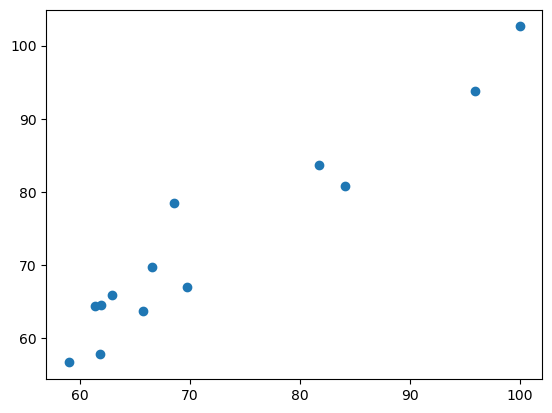

In [27]:
plt.scatter(y_test , y_pred) # ne kadar doğrusal ise o kadar doğruluk oranı yuksek tahminler var diyeibiliriz

In [28]:
residual = y_test - y_pred

In [29]:
residual # test - tahmin arasındaki fark miktarı

35    2.652956
37    3.894544
41   -1.930848
26    2.006006
38   -3.130796
43    3.335144
3     2.135550
33   -3.039535
30   -2.686757
36   -9.822961
14    2.321394
16   -3.040466
20   -2.604386
Name: Exam Score, dtype: float64

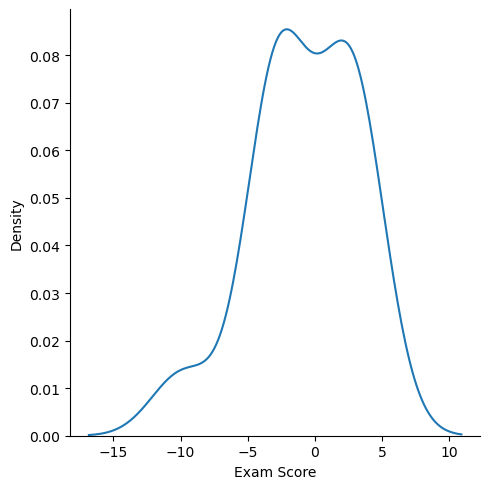

In [30]:
sns.displot(residual , kind = 'kde')

In [31]:
regression.intercept_

np.float64(77.41081081081082)

In [32]:
regression.coef_ # Kolonun exam score 'a ne oranda veya ne ağırlıkta etki ettiğini görebilir karşılaştırabilirz

array([ 9.28014703,  1.78967062,  3.24340001, -4.08127695])